# Linear Regression

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Pearson Heights Dataset

The following is a classical dataset for regression. It contains data on heights of father-adult son pairs. 

In [64]:
height = pd.read_csv("PearsonHeightData.txt", sep = r"\s+")
print(height)

      Father   Son
0       65.0  59.8
1       63.3  63.2
2       65.0  63.3
3       65.8  62.8
4       61.1  64.3
...      ...   ...
1073    67.0  70.8
1074    71.3  68.3
1075    71.8  69.3
1076    70.7  69.3
1077    70.3  67.0

[1078 rows x 2 columns]


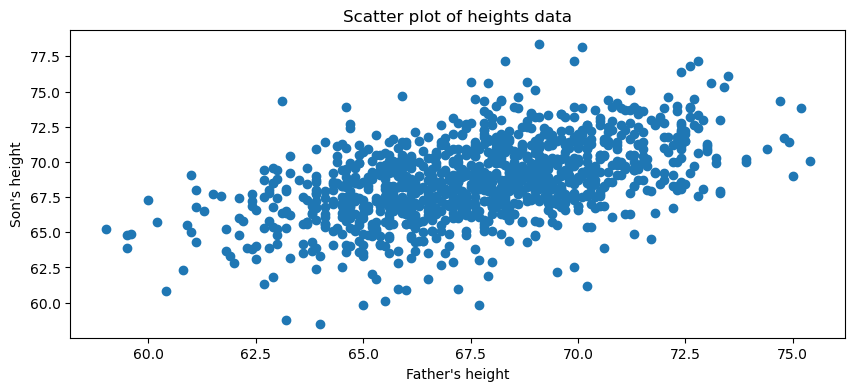

In [65]:
plt.figure(figsize = (10, 4))
plt.scatter(height["Father"], height["Son"])
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

We will fit a linear regression model with $y$ taken to be Son's height, and $x$ taken to be Father's height. Here there is only one covariate (i.e., $m = 1$) so it is called simple linear regression. We shall use the statsmodels library to fit regressions. 

In [66]:
n = height.shape[0]
X = np.column_stack([np.ones(n), height["Father"]]) #this is the X matrix (consisting of covariates and the column of ones)
y = height["Son"] #this is the y vector consisting of response values


In [67]:
linmod = sm.OLS(y, X).fit()
print(linmod.summary())


                            OLS Regression Results                            
Dep. Variable:                    Son   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     360.9
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.27e-69
Time:                        15:00:35   Log-Likelihood:                -2489.4
No. Observations:                1078   AIC:                             4983.
Df Residuals:                    1076   BIC:                             4993.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8928      1.833     18.491      0.0

In [68]:
bhat = linmod.params.values
print(bhat)
Sbhat = np.sum(linmod.resid ** 2)
m = X.shape[1] - 1 #in this case, m = 1
sighat = np.sqrt(Sbhat/(n-m-1)) #this is also called the residual standard error
print(sighat)

[33.89280054  0.51400591]
2.438134379352427


Below we plot the data along with the fitted regression line. 

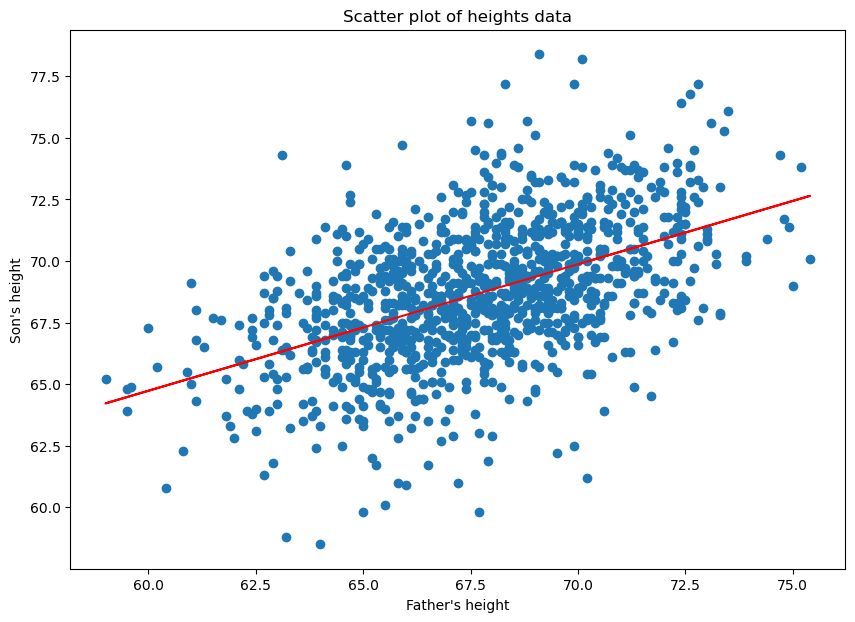

In [69]:
plt.figure(figsize = (10, 7))
plt.scatter(height["Father"], height["Son"])
x = height["Father"].values
plt.plot(x, linmod.fittedvalues, 'r')
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

To visualize the uncertainty associated with the regression line, we can draw $(\beta_0, \beta_1)$ from the posterior distribution: 
\begin{align*}
   \beta \mid \text{data} \sim t_{m+1} \left(\hat{\beta}, \hat{\sigma}^2 (X^T X)^{-1}, n - m - 1 \right). 
\end{align*}
where $\hat{\sigma}^2 = S(\hat{\beta})/(n-m-1)$. The matrix $\frac{S(\hat{\beta})}{n-m-1} (X^T X)^{-1}$ is actually calculated as part of the sm.OLS output, and can be obtained as follows:

In [70]:
m = X.shape[1] - 1 #in this case, m = 1
n = len(y)
Sigma = Sbhat / (n - m - 1) * np.linalg.inv(X.T @ X)
print(Sigma)

print(linmod.cov_params()) #this coincides with Sigma calculated above. Check out help(linmod.cov_params) for more details.


[[ 3.35950253e+00 -4.95515638e-02]
 [-4.95515638e-02  7.32071005e-04]]
          const        x1
const  3.359503 -0.049552
x1    -0.049552  0.000732


To generate observations from the $t$-distribution mentioned above, we shall use an inbuilt function from scipy:

In [73]:
from scipy.stats import multivariate_t
N = 1000 #number of samples to generate
beta_samples = multivariate_t.rvs(loc=bhat, shape=Sigma, df=n - m - 1, size=N)
print(beta_samples)

[[34.72575693  0.50016309]
 [30.45729673  0.5646729 ]
 [32.13837875  0.53972836]
 ...
 [35.57193359  0.49104072]
 [35.0390515   0.49613476]
 [33.37923316  0.52072394]]


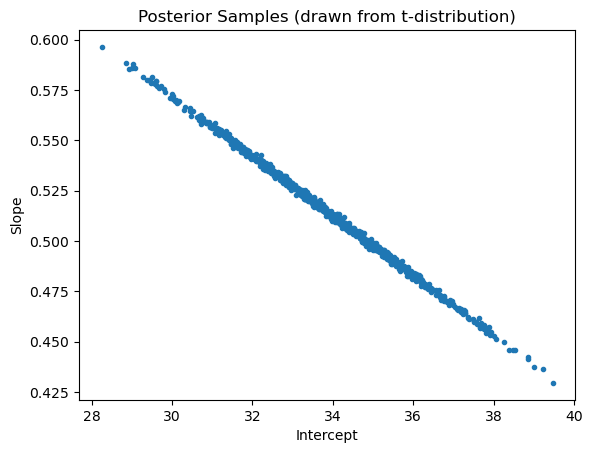

In [74]:
import matplotlib.pyplot as plt
plt.scatter(beta_samples[:,0], beta_samples[:,1], marker = '.')
plt.xlabel('Intercept')
plt.ylabel('Slope')
plt.title('Posterior Samples (drawn from t-distribution)')
plt.show()

In [ ]:
plt.figure(figsize = (10, 7))
plt.scatter(height["Father"], height["Son"])
x = height["Father"].values
for r in range(N): 
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(x, fvalsnew, color = 'orange')
plt.plot(x, linmod.fittedvalues, 'r')
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

In class we looked at Bayesian linear regression. Here we use the default prior: 
\begin{align*}
   \beta_0, \dots, \beta_m, \log \sigma \overset{\text{i.i.d}}{\sim} \text{uniform}(-C, C)
\end{align*}
for $C \rightarrow \infty$. Bayesian inference with this prior basically coincides with frequentist inference. Today, we shall look at some standard regression terminology and also how some of the numbers shown in the regression output are actually computed. We shall use the statsmodels library to compute linear regression output. 

To keep things simple, we shall illustrate multiple linear regression with a very simple dataset. This is the US GDP dataset from FRED (https://fred.stlouisfed.org/series/GDP) which gives quarterly data on the Gross Domestic Product (units are billions of dollars).

In [75]:
import pandas as pd
gdp = pd.read_csv('GDP_12Nov2025.csv')
display(gdp)

,observation_date,GDP
0,1947-01-01,243.164
1,1947-04-01,245.968
2,1947-07-01,249.585
3,1947-10-01,259.745
4,1948-01-01,265.742
...,...,...
309,2024-04-01,29147.044
310,2024-07-01,29511.664
311,2024-10-01,29825.182
312,2025-01-01,30042.113


The key variable is GDP. Below we plot it against time. 

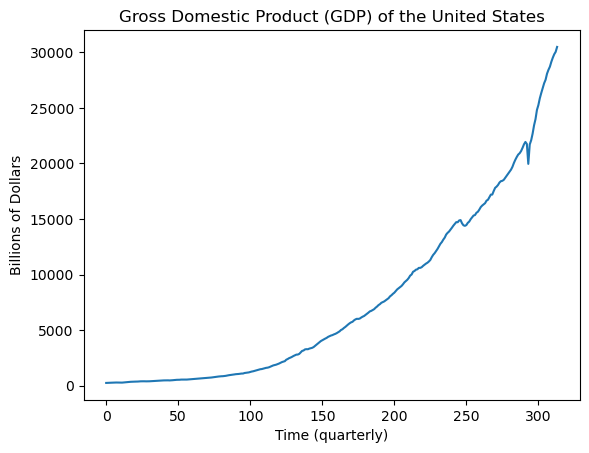

In [76]:
import matplotlib.pyplot as plt
plt.plot(gdp['GDP'])
plt.xlabel("Time (quarterly)")
plt.ylabel("Billions of Dollars")
plt.title("Gross Domestic Product (GDP) of the United States")
plt.show()

We take the GDP data to be the response variable $y$. We shall fit a multiple linear regression to this data with three covariates: $x_1, x_2, x_3$. $x_1$ is simply time $t = 1, \dots, n$, $x_2$ is the square of time, and $x_3$ is the cube of time. In other words, we fit a cubic model of time to the data. 

Let us fit a cubic trend model to this dataset given by: 
\begin{equation*}
  y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \beta_3 t^3 + \epsilon_t
\end{equation*}
for $t = 1, \dots, n$ where $n$ is the total number of observations in the dataset. In vector-matrix notation, this model can be equivalently be represented as: 
\begin{equation*}
   y = X \beta + \epsilon
\end{equation*}
where
\begin{equation*}
   y = \begin{pmatrix} y_1\\ y_2 \\ \cdot \\ \cdot \\ \cdot \\ y_n \end{pmatrix} ~~~
   X = \begin{pmatrix} 1 & 1 & 1 & 1 \\ 1 & 2 & 2^2 & 2^3 \\ 1 & 3 & 3^2 & 3^3 \\ \cdot & \cdot & \cdot & \cdot \\ \cdot & \cdot & \cdot & \cdot \\ \cdot & \cdot & \cdot & \cdot \\ 1 & n & n^2 & n^3 \end{pmatrix} ~~~ \beta = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \beta_3 \end{pmatrix} ~ ~ ~ \epsilon = \begin{pmatrix} \epsilon_1 \\ \epsilon_2 \\ \cdot \\ \cdot \\ \cdot \\ \epsilon_n \end{pmatrix}
\end{equation*}
Observe $y$ is $n \times 1$, $X$ is $n \times 4$, $\beta$ is $4 \times 1$ and $\epsilon$ is $n \times 1$. The entries $\epsilon_1, \dots, \epsilon_n$ of the vector $\epsilon$ are known as errors and we assume that $\epsilon_i \overset{\text{i.i.d}}{\sim} N(0, \sigma^2)$. There are 5 parameters in this model $\beta_0, \beta_1, \beta_2, \beta_3, \sigma$ which we need to estimate from the data. 

To implement regression using statsmodels, we simply need to create $y$ and $X$ and give them as input to the sm.OLS function. 

The following code creates $y$ and $X$. 

In [77]:
import numpy as np
y = gdp['GDP']
n = len(y)
x = np.arange(1, n + 1)
x2 = x ** 2
x3 = x ** 3
import numpy as np
X = np.column_stack([np.ones(n),x, x2, x3])
print(X)


[[1.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00]
 [1.0000000e+00 2.0000000e+00 4.0000000e+00 8.0000000e+00]
 [1.0000000e+00 3.0000000e+00 9.0000000e+00 2.7000000e+01]
 ...
 [1.0000000e+00 3.1200000e+02 9.7344000e+04 3.0371328e+07]
 [1.0000000e+00 3.1300000e+02 9.7969000e+04 3.0664297e+07]
 [1.0000000e+00 3.1400000e+02 9.8596000e+04 3.0959144e+07]]


Now we simply use sm.OLS with $y$ and $X$: 

In [78]:
import statsmodels.api as sm
md = sm.OLS(y, X).fit()
print(md.summary())

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.760e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:03:33   Log-Likelihood:                -2458.4
No. Observations:                 314   AIC:                             4925.
Df Residuals:                     310   BIC:                             4940.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        180.6117    139.806      1.292      0.1

### Least Squares Estimates

The information on the estimates $\hat{\beta}_0, \hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3$ along with associated uncertainties (standard errors) are given in the table near the middle of the output. Specifically, the estimates from the above table are $\hat{\beta}_0 = 180.6117$, $\hat{\beta}_1 = 2.7137$, $\hat{\beta}_2 = 0.0252$ and $\hat{\beta}_3 = 0.0008$. These numbers can also be obtained using model.params as follows:

In [79]:
print(md.params)

const    180.611745
x1         2.713731
x2         0.025245
x3         0.000791
dtype: float64



These estimates are known as the Least Squares Estimates (also the same as Maximum Likelihood Estimates) and they are computed via the formula: 
\begin{equation*}
   \hat{\beta} = \begin{pmatrix} \hat{\beta}_0 \\ \hat{\beta}_1 \\ \hat{\beta}_2 \\ \hat{\beta}_3 \end{pmatrix} = (X^T X)^{-1} X^T y. 
\end{equation*}
Let us verify that this formula indeed gives the reported estimates. 

In [80]:
XTX = np.dot(X.T, X)
XTX_inverse = np.linalg.inv(XTX)
XTX_inverse_XT = np.dot(XTX_inverse, X.T)
betahat = np.dot(XTX_inverse_XT, y)
print(np.column_stack([betahat, md.params]))

[[1.80611745e+02 1.80611745e+02]
 [2.71373086e+00 2.71373086e+00]
 [2.52451671e-02 2.52451671e-02]
 [7.90735172e-04 7.90735172e-04]]


In reality, sm.OLS does not use the above formula directly (even though the formula is the correct one), instead it uses some efficient linear algebra methods to solve the linear equations $X^T X \beta = X^T y$.

### Fitted Values

The next quantity to understand are the fitted values. These are given by model.fittedvalues and they are obtained via the simple formula: 
\begin{equation*}
   \hat{y} = X \hat{\beta}
\end{equation*}
The entries $\hat{y}_1, \dots, \hat{y}_n$ of the vector $\hat{y}$ are known as the fitted values. Let us check the correctness of this formula. 

In [81]:
fvals = np.dot(X, betahat)
print(np.column_stack([fvals[:10], md.fittedvalues[:10]]))

[[183.35151151 183.35151151]
 [186.14651301 186.14651302]
 [189.00149368 189.00149368]
 [191.92119791 191.92119791]
 [194.91037012 194.91037012]
 [197.97375471 197.97375472]
 [201.11609611 201.11609611]
 [204.34213872 204.34213872]
 [207.65662695 207.65662695]
 [211.06430522 211.06430522]]


To assess how well the regression model fits the data, we plot the fitted values along with the original data. 

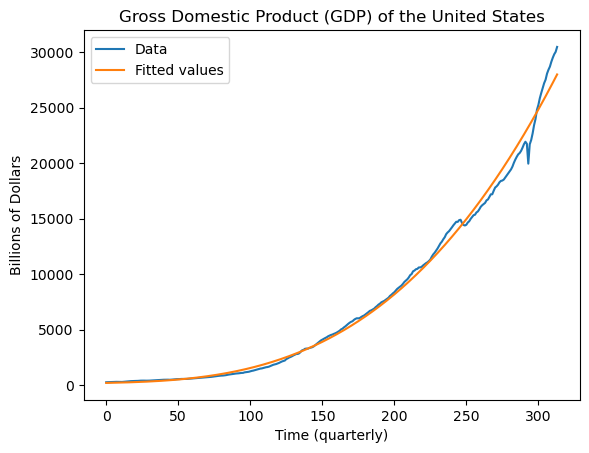

In [82]:
plt.plot(y, label = "Data")
plt.plot(md.fittedvalues, label = "Fitted values")
plt.legend()
plt.xlabel("Time (quarterly)")
plt.ylabel("Billions of Dollars")
plt.title("Gross Domestic Product (GDP) of the United States")
plt.show()

### Residuals

The residuals simply are the differences between the observed data and the fitted values. We use the notation $e$ for the vector of residuals:
\begin{equation*}
  e = y - \hat{y}
\end{equation*}
The $i^{th}$ residual is simply the $i^{th}$ entry of $e$. 

In [83]:
residuals = y - fvals
print(np.column_stack([md.resid[:10], residuals[:10]]))

[[59.81248849 59.81248849]
 [59.82148698 59.82148699]
 [60.58350632 60.58350632]
 [67.82380209 67.82380209]
 [70.83162988 70.83162988]
 [74.59324528 74.59324529]
 [78.07990389 78.07990389]
 [76.02386128 76.02386128]
 [67.37737305 67.37737305]
 [60.28669478 60.28669478]]


A plot of the residuals against time is an important diagnostic tool which can tell us about the effectiveness of the fitted model. 

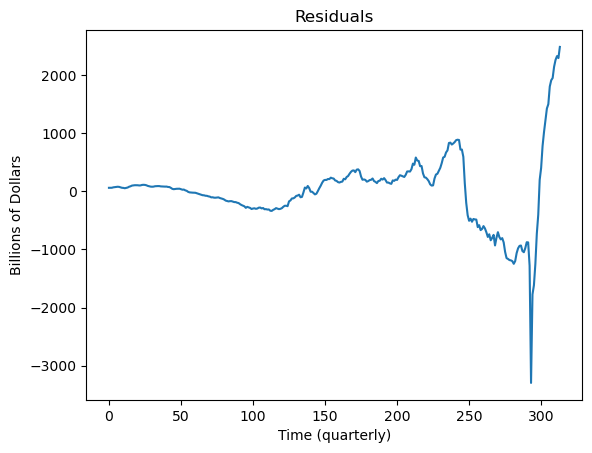

In [84]:
plt.plot(md.resid)
plt.xlabel("Time (quarterly)")
plt.ylabel("Billions of Dollars")
plt.title("Residuals")
plt.show()

From this plot, we see that there are some very large residuals indicating the presence of time points where the model predictions are quite far off from the observed values. This could be because of outliers or some systematic features that the model is missing. 

In [ ]:
#the value of the last residual
md.resid[n-1]

### Residual Sum of Squares (RSS) and Residual df 

Two other commonly used terms (in connection with residuals) are the Residual Sum of Squares (RSS) and the Residual Degrees of Freedom. The RSS is simply the sum of the squares of the residuals: 
\begin{equation*}
   \text{RSS} = \sum_{i=1}^n e_i^2 = \sum_{t=1}^n \left(y_t - \hat{\beta}_0 - \hat{\beta}_1 t - \hat{\beta}_2 t^2 - \hat{\beta}_3 t^3 \right)^2
\end{equation*}
RSS is simply equal to the smallest possible of the sum of squares criterion $S(\hat{\beta}_0, \hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3)$ (recall from lecture that $S(\beta_0, \beta_1, \beta_2, \beta_3) = \sum_{t=1}^n (y_t - \beta_0 - \beta_1 t - \beta_2 t^2 - \beta_3 t^3)^2$).

The vector of residuals has the following important property: $X^T e = 0$. This can be proved as follows: 
\begin{equation*}
   X^T e = X^T (y - \hat{y}) = X^T (y - X \hat{\beta}) = X^T (y - X (X^T X)^{-1} X^T y) = X^T y - X^T X (X^T X)^{-1} X^T y = X^T y - X^T y = 0. 
\end{equation*}
$X^T e = 0$ means that the dot product between every column of $X$ and $e$ equals 0. In our regression model for GDP, $X^T e = 0$ is equivalent to: 
\begin{equation*}
   \sum_{t = 1}^n e_t = 0 ~~~~  \sum_{t = 1}^n t e_t = 0 ~~~~  \sum_{t = 1}^n t^2 e_t = 0 ~~~~  \sum_{t = 1}^n t^3 e_t = 0
\end{equation*}
Even though there are $n$ residuals $e_1, \dots, e_n$, they have to satisfy the above four equality constraints. Therefore, the effective number of 'free' residuals is $n-4$. Thus the residual degrees of freedom equals $n-4$. 

More generally, the residual df equals the number of observations ($n$) minus the number of columns in the $X$ matrix. 

### Estimate of $\sigma$: the residual standard error

The estimate of $\sigma$ is given by: 
\begin{equation*}
   \hat{\sigma} = \sqrt{\frac{RSS}{n-4}} = \sqrt{\frac{S(\hat{\beta}_0, \hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3)}{n-4}}
\end{equation*}
This quantity is sometimes called the Residual Standard Error. The value of the Residual Standard Error can be used to assess the size of the residuals (residuals much larger than say twice the Residual Standard Error indicate points where the model fits particularly poorly).

In [85]:
rss = np.sum(md.resid ** 2)
rse = np.sqrt(rss/(n - 4))
print(rse)

611.9599669724936


This intuitively means that residuals with magnitude above $2*\text{rse} \approx 1200$ are points where the model fits particularly poorly. From a look at the plot of the residuals against time, there are many residuals which are this large in magnitude. 

### Standard Errors of the coefficient estimates

The standard errors corresponding to $\hat{\beta}_0, \hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3$ are the square roots of the diagonal entries of $\hat{\sigma}^2 (X^T X)^{-1}$. They are given by md.bse as verified below. 

In [86]:
sebetahat_squared = (rse ** 2)*(np.diag(XTX_inverse))
sebetahat = np.sqrt(sebetahat_squared)
print(np.array([md.bse, sebetahat]))

[[1.39805910e+02 3.83755953e+00 2.82852061e-02 5.90308579e-05]
 [1.39805910e+02 3.83755953e+00 2.82852061e-02 5.90308579e-05]]


### t-statistic and confidence intervals for the coefficients

The $t$-statistic for each coefficient is simply the estimate divided by the standard error. The confidence interval for $\beta_j$ is given by:
\begin{equation*}
   \left[\hat{\beta}_j - t_{\alpha/2, n-4} \text{ standard error of } \hat{\beta}_j, \hat{\beta}_j + t_{\alpha/2, n-4} \text{ standard error of } \hat{\beta}_j  \right]
\end{equation*}
where $t_{\alpha/2, n-4}$ is the point beyond the $t$-distribution with $n-4$ degrees of freedom gives probability mass $\alpha/2$. The above formula is the result of: 
\begin{equation*}
   \frac{\beta_j - \hat{\beta}_j}{\text{ standard error of } \hat{\beta}_j} \mid \text{ data } \sim t-\text{distribution with} ~n-4 \text{ d.f}
\end{equation*}
The above statement can also be interpreted in a frequentist sense (then the conditional on data will be removed and the randomness will be over the data with fixed $\beta_j$).

In [87]:
from scipy.stats import t
alpha = 0.05
qt = t.ppf(1 - (alpha/2), n-4) #area to the right equaling alpha/2 is the same as area to the left equaling 1-alpha/2
print(qt)
cilower = md.params - md.bse*qt
ciupper = md.params + md.bse*qt
print(np.column_stack([cilower, ciupper]))
print(md.summary())


1.967645928777568
[[-9.44767854e+01  4.55700275e+02]
 [-4.83722752e+00  1.02646892e+01]
 [-3.04101036e-02  8.09004378e-02]
 [ 6.74583344e-04  9.06886999e-04]]
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.760e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:05:28   Log-Likelihood:                -2458.4
No. Observations:                 314   AIC:                             4925.
Df Residuals:                     310   BIC:                             4940.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>

### Visualizing Uncertainty

It was showed in Lecture that the posterior distribution of $\beta$ (this is the vector of coefficients) is given by
\begin{equation*}
   \beta \mid \text{data} \sim t_{n-4, 4} \left(\hat{\beta}, \hat{\sigma}^2 (X^T X)^{-1} \right)
\end{equation*}
From the definition of the $t$-distribution above, we also know that the distribution above coincides with the distribution of
\begin{equation*}
    \hat{\beta} + \frac{Z}{\sqrt{V/(n-4)}}
\end{equation*}
where $Z \sim N(0, \hat{\sigma}^2 (X^T X)^{-1})$ and $V \sim \chi^2_{n-4}$ are independent. Using this, we can generate vectors $\beta$ from their posterior distribution and then plot the regression curves corresponding to the different generated $\beta$ vectors. This will give us an idea of the uncertainty underlying the coefficients. 


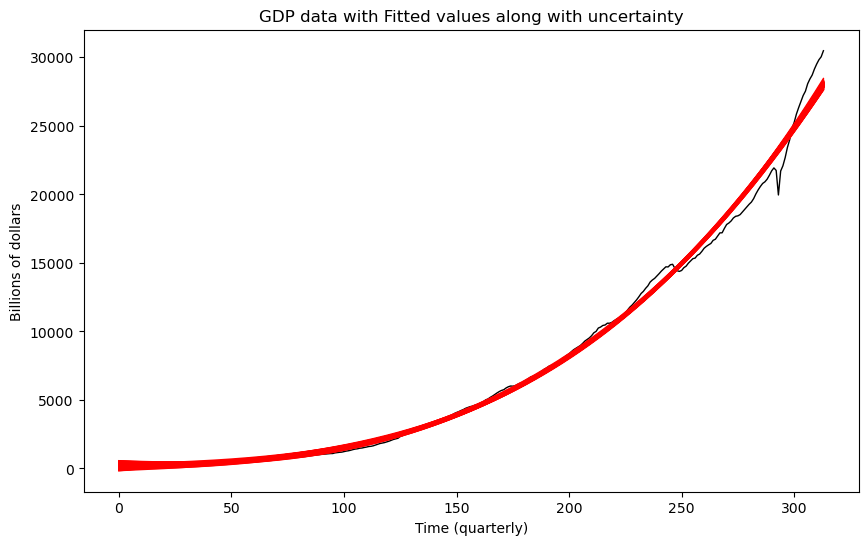

In [88]:
N = 200 #this the number of posterior samples that we shall draw
Sigma_mat = (rse ** 2)*(XTX_inverse)
#print(Sigma_mat)

from scipy.stats import chi2, multivariate_normal

chi_samples = chi2(df = n-4).rvs(N)
norm_samples = multivariate_normal(cov = Sigma_mat, allow_singular = True).rvs(N)
post_samples = np.tile(betahat, (N, 1)) + norm_samples / np.sqrt(chi_samples / (n-4))[:, None]
#print(post_samples)

plt.figure(figsize = (10, 6))
plt.plot(y, linewidth = 1, color = 'black')
for k in range(N):
    fvalsnew = np.dot(X, post_samples[k])
    plt.plot(fvalsnew, color = 'red', linewidth = 1)
plt.xlabel('Time (quarterly)')
plt.ylabel('Billions of dollars')
plt.title('GDP data with Fitted values along with uncertainty')
plt.show()

Even though $N = 200$ regression curves have been plotted, they are still fairly clustered together. This suggests that the uncertainty in these estimates is fairly small. 

## A Time Series Dataset (Personal Consumption Expenditures from FRED)

The following data is on personal consumption expenditures from FRED (https://fred.stlouisfed.org/series/PCEC). It measures the total amount of money that U.S. households spend on goods and services. This is a time-series record of that spending reported quarterly in billions of dollars (with seasonal adjustment). This measure is compiled by the Bureau of Economic Analysis (BEA) and is a key indicator used to track consumer demand and overall economic activity in the United States.

  observation_date     PCEC
0       1947-01-01  156.161
1       1947-04-01  160.031
2       1947-07-01  163.543
3       1947-10-01  167.672
4       1948-01-01  170.372


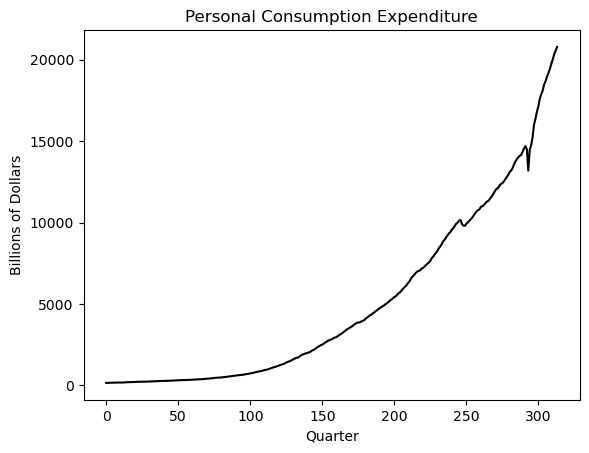

In [89]:
pcec = pd.read_csv("PCEC_30Oct2025.csv")
print(pcec.head())
y = pcec['PCEC'].to_numpy()
plt.plot(y, color = 'black')
plt.xlabel('Quarter')
plt.ylabel('Billions of Dollars')
plt.title('Personal Consumption Expenditure')
plt.show()

Let us fit the AR(1) model to this dataset. This is just linear regression with $y_t$ as response and $y_{t-1}$ as the covariate. We can fit this by manually creating $y = y_t$ and $x = y_{t-1}$ and using the sm.OLS function. 

In [90]:
p = 1
n = len(y)
yreg = y[p:] #these are the response values in the autoregression
Xmat = np.ones((n-p, 1)) #this will be the design matrix (X) in the autoregression
for j in range(1, p+1):
    col = y[p-j : n-j].reshape(-1, 1)
    Xmat = np.column_stack([Xmat, col])

armod = sm.OLS(yreg, Xmat).fit()
print(armod.params)
print(armod.summary())

[5.06629868 1.01215697]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.086e+05
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:07:07   Log-Likelihood:                -1949.1
No. Observations:                 313   AIC:                             3902.
Df Residuals:                     311   BIC:                             3910.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0663      9

There is also an in-built function (called AutoReg) in statsmodels for fitting AR models. We can directly use it. 

In [91]:
from statsmodels.tsa.ar_model import AutoReg
armod_sm = AutoReg(y, lags = p).fit()
print(armod_sm.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  314
Model:                     AutoReg(1)   Log Likelihood               -1949.118
Method:               Conditional MLE   S.D. of innovations            122.520
Date:                Thu, 25 Jun 2026   AIC                           3904.236
Time:                        15:08:03   BIC                           3915.475
Sample:                             1   HQIC                          3908.728
                                  314                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0663      9.480      0.534      0.593     -13.514      23.647
y.L1           1.0122      0.001    782.656      0.000       1.010       1.015
                                    Roots           

Here are some observations comparing the above two outputs:  
1. The parameter estimates are exactly the same.
2. The regression summary gives t-scores corresponding to each parameter estimate while the AutoReg summary only gives z-scores
3. The standard errors are slightly different.

The standard errors given by the regression summary correspond to the square roots of the diagonal entries of: 
\begin{equation*}
   \hat{\sigma}^2 (X^T X)^{-1} ~~~ \text{ where } \hat{\sigma}^2 = \sqrt{\frac{\|Y - X \hat{\beta}\|^2}{n-2p-1}}
\end{equation*}
while the standard errors reported by AutoReg summary correspond to the square roots of the diagonal entries of:
\begin{equation*}
   \hat{\sigma}_{\text{MLE}}^2 (X^T X)^{-1} ~~~ \text{ where } \hat{\sigma}_{\text{MLE}}^2 = \sqrt{\frac{\|Y - X \hat{\beta}\|^2}{n-p}}
\end{equation*}